# SynBIC Bioinformatics Seminar: Introduction to PCA, Clustering and Data Analysis, Part 2

___

#### Overview and Motivation

We have previously covered PCA as a linear transform to map data in a way that captures the most variation in a dataset. From the Iris dataset, we could identify a clear separation of the datapoints into (at least) two groups. In an attempt to classify these points into **classes**, a number of different clustering approaches may be employed.


___

#### Summary of this notebook
- Introduction to the need for clustering.
- Supervised vs unsupervised methods.
- K-means, Gaussian Mixture Models, Leiden and HDBSCAN methods of clustering.
- Variability in a method due to randomness.
- The effect of separated vs continuous manifolds.

In [2]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#### sets format of plots to SVG, just a personal preference for better quality plots
%config InlineBackend.figure_format = 'svg'

#### Continuing from last time...
___


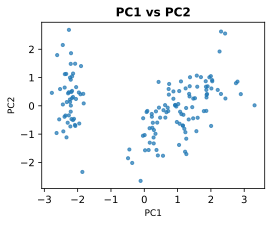

In [3]:
#### Quickly replicate the workflow from notebook 00

iris_df = pd.DataFrame(data=load_iris().data, columns=load_iris().feature_names)

scaled_data = StandardScaler().fit_transform(iris_df)
iris_model = PCA().fit(scaled_data)
iris_pca_df = iris_model.transform(scaled_data)
iris_pca_df = pd.DataFrame(
    iris_pca_df,
    columns=[f"PC{i+1}" for i in range(iris_pca_df.shape[1])]
)

#### Plot PC1 vs PC2 as a scatter plot

plt.figure(figsize=(4, 3))
plt.scatter(
    iris_pca_df['PC1'],
    iris_pca_df['PC2'],
    s=10,
    alpha=0.7
)
plt.xlabel('PC1', fontsize=9)
plt.ylabel('PC2', fontsize=9)
plt.title('PC1 vs PC2', fontsize=12, fontweight='bold')
plt.show()


#### The need for clustering
___
As mentioned at the end of the previous notebook, the PCA technique is often used to reveal distributions that are not particularly obvious just by looked at feature relations in the raw data. From the plot above, we can clearly see the datapoints partition themselves into two clear groups, indicating at least two **classes** (classifications) of the data can rationally be inferred. Since this is a toy dataset, one only needs to visit the [Iris Dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris) from sklearn to see the true number of classes. In reality, we often do not have this luxury with data measurements. This uncertainty motivates a need for effective clustering techniques in order to best classify nature, though the philosophical debate of whether the human nature of desiring to discretely classify everything it sees is rational is beyond the scope of this workshop ;).

#### Quick briefing on supervised and unsupervised methods
___
It is important to understand that everything that has been covered thus far falls into the domain of machine learning. Clustering methods are no different. At a fundamental level, the difference between supervised and unsupervised methods stems from whether the model relies on a pre-labelled training data or well-defined answers. Whilst some supervised clustering algorithms do exist, the most commonly used ones are unsupervised, and are the focus of this workshop.

The clustering methods taught here are summarised below:
- k-means.
- Gaussian Misture Models (GMM).
- Leiden clustering.
- Hierarchical Density-Based Spatial Clustering of Applications with Noise (HDBSCAN).

#### k-means
___
k-means is one of the simplest clustering algorithms out there and works as this:
1) user manually chooses *k* random points to be centroids (the middle of the cluster).
2) assign every point in the dataset to its closest centroid.
3) Recalculate the each centroid as the mean of the points in the corresponding cluster.
4) Re-iterate until convergence.

c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


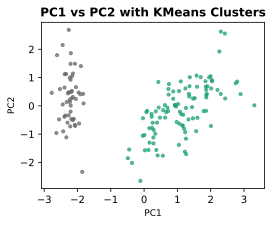

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,   # choose the number of clusters you want to find.
    random_state=1  # setting the random state ensures that results are reproducible.
    )

labels = kmeans.fit_predict(iris_pca_df)

plt.figure(figsize=(4, 3))
plt.scatter(
    iris_pca_df['PC1'],
    iris_pca_df['PC2'],
    c=labels,
    cmap='Dark2',
    s=10,
    alpha=0.7
)
plt.xlabel('PC1', fontsize=9)
plt.ylabel('PC2', fontsize=9)
plt.title('PC1 vs PC2 with KMeans Clusters', fontsize=12, fontweight='bold')
plt.show()

<details>
<summary>The above plot shows the now-labelled data after a k-means algorithm has been implemented. However, there is a pretty clear drawback to k-means. Can you think of what it is?</summary>

One needs to manually choose the number of clusters (*k*) for this algorithm. This can be problematic as it relies on the user rationally choosing a good number, and it is a drawback not unique to k-means. Obviously, good scientists don't choose this number arbitrarily if they decide to take this approach, and use a number of different criterions and metrics to guide and justify their selection of *k*.

Here we focus on the two most standard ones, which complement each other. These are the **Elbow Method** and the **Silhouette Score**.

Let us trial three different values of *k*: 2, 3 and 4.
</details>

#### The Silhouette Score

The Silhouette Score is calculated as so: if we let *a* be the mean intra-cluster distance and *b* is the mean nearest-cluster distance for a single data point, then the Silhouette Coefficient is:

```math
(a-b) / max(a,b)
```

Such that values are constrained between 1 (best outcome) and -1 (worst outcome). Values near 0 indicate overlapping clusters. Negative values generally indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar.

In [19]:
from sklearn.metrics import silhouette_score

trialled_ks = [2, 3, 4]

for n_clusters in trialled_ks:
    labels = KMeans(
        n_clusters=n_clusters, 
        random_state=1
        ).fit_predict(iris_pca_df)
    silhouette_avg = silhouette_score(iris_pca_df, labels)
    print(f'Silhouette Score for {n_clusters} clusters: {silhouette_avg:.2f}')


Silhouette Score for 2 clusters: 0.58
Silhouette Score for 3 clusters: 0.46
Silhouette Score for 4 clusters: 0.42


c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#### The Elbow Method

The Elbow Method helps choose the number of clusters *k*. We plot the **within-cluster variance** using the **WCSS metric** (Within-Cluster Sum of Squares), sometimes also called intertia. The user picks the "elbow point" which corresponds to where adding more clusters has a marginal reduction effect on WCSS.

c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak o

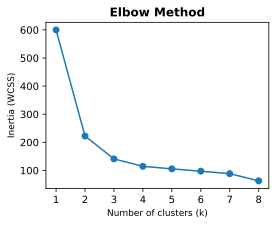

In [8]:
trialled_ks = range(1, 9)
inertias = [KMeans(n_clusters=k, random_state=1).fit(iris_pca_df).inertia_ for k in trialled_ks]

plt.figure(figsize=(4, 3))
plt.plot(trialled_ks, inertias, marker='o')
plt.xticks(trialled_ks)
plt.xlabel('Number of clusters (k)', fontsize=9)
plt.ylabel('Inertia (WCSS)', fontsize=9)
plt.title('Elbow Method', fontsize=12, fontweight='bold')
plt.show()

To finish off this section on k-means, let us properly conclude what the Silhouette Score and Elbow Plots achieve, for they are different but complementary methods and by no means alternatives over each other. The Silhouette Score is a validation measure for good clustering, calculated from the comparison of mean within-cluster distance against mean outside-cluster distance. The Elbow Method is simply a decision rule for initialising *k*. Finally, one must recognise that these are mere tools for helping the user achieve a more confident decision, but remain crude in their approach.

#### Gaussian Mixture Models
___
1. Choose a number of clusters, and initialise each cluster as a Gaussian distribution with its own mean and variance.
2. For every data point, compute the probability of belonging to each Gaussian.
3. Update each Gaussian's parameters to better fit the data.
4. Reiterate until convergence.

Similar idea to k-means, but GMM: (1) can model clusters with different shapes; and (2) returns probabilities of belonging to each cluster rather than a single fixed assignment.

c:\Users\Tristan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


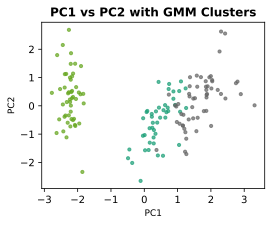

In [17]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=6)
labels = gmm.fit_predict(iris_pca_df)

plt.figure(figsize=(4, 3))
plt.scatter(
    iris_pca_df['PC1'],
    iris_pca_df['PC2'],
    c=labels,
    cmap='Dark2',
    s=10,
    alpha=0.7
)
plt.xlabel('PC1', fontsize=9)
plt.ylabel('PC2', fontsize=9)
plt.title('PC1 vs PC2 with GMM Clusters', fontsize=12, fontweight='bold')
plt.show()

There are three common criterions for optimising the number of components in GMM clustering: (1) Bayesian Inference Score; (2) Akaike Information Criterion; and (3) Silhouette Score, which has already been covered.

#### Variation in an outcome due to randomness
___
To conclude this workshop on clustering, I would like to present to you this caveat of clustering in research that can lead the naive scientist astray in their analyses. Indeed, we have thus far covered four strategies to clustering ___